# Cosmic Intelligence Lab

## Deep Galaxy Explorer — Study 001

# Notebook 009 — Cluster Galaxies with Unsupervised Learning

---

## Research Question

Can an unsupervised machine learning algorithm identify natural groupings
within a population of galaxies using only their measured physical properties?

---

## Objectives

- Load the machine learning feature table
- Prepare the feature matrix
- Standardize feature values
- Apply K-Means clustering
- Visualize the resulting clusters
- Interpret the discovered galaxy populations

# Notebook 008 — Extract Machine Learning Features

## Objective

In this notebook we transform each detected astronomical source into a set of
numerical features suitable for machine learning.

Rather than working directly with image pixels, we extract measurable properties
such as brightness, size, shape, and position. These measurements form a
feature table in which every row represents one astronomical object and every
column represents a measurable characteristic.

This notebook represents the transition from image processing to machine
learning and data science.

In [1]:
# Cell 2 - Import Libraries ===================================

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from astropy.table import Table

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
# Cell 3 - Load Machine Learning Features ======================

features = Table.read(
    Path("../data/catalogs/ml_features.ecsv"),
    format="ascii.ecsv"
)

print(f"Loaded {len(features)} astronomical objects.")
print(features.colnames)

Loaded 95 astronomical objects.
['segment_flux', 'area', 'semimajor_axis', 'semiminor_axis', 'eccentricity', 'orientation', 'axis_ratio', 'flux_per_pixel']


In [3]:
# Cell 4 - Inspect Feature Matrix ==============================

features[:10]

segment_flux,area,semimajor_axis,semiminor_axis,eccentricity,orientation,axis_ratio,flux_per_pixel
,pix2,pix,pix,,deg,pix,
float64,float64,float64,float64,float64,float64,float64,float64
103.97923684120178,24.0,2.1532985095548427,1.4546436878746936,0.7373214628932244,59.68625869106634,1.4802927531352494,4.332468201716741
19.497517228126526,16.0,1.0425375485147124,0.8473819282730207,0.5825329240047639,30.763603254853948,1.2303042037247858,1.2185948267579079
31.58135676383972,16.0,0.8541513400365031,0.7580456582502352,0.4608385055033623,277.7009772993434,1.1267808617334536,1.9738347977399826
6.465743601322174,6.0,0.6440643877584695,0.5514238892637224,0.516706370668758,294.4995327788689,1.1680023305091904,1.0776239335536957
24.018874406814575,32.0,2.2941649471403283,1.4005674373639603,0.7920230641969821,303.90657994640236,1.6380253359725598,0.7505898252129555
12.340121269226074,15.0,1.063488324717736,0.9223128857493856,0.497868595189019,271.8012506450832,1.1530667533216175,0.8226747512817383
11.399610340595245,13.0,1.0771237638461464,0.7989851718607586,0.6706470897789912,45.38350344446989,1.3481148358956776,0.8768931031227112
6.043212354183197,10.0,1.13510003434925,0.6721785777757441,0.805808924882241,318.5683560480159,1.6886882026281242,0.6043212354183197


In [4]:
# Cell 5 - Select Physical Features ============================

feature_names = [
    "segment_flux",
    "area",
    "semimajor_axis",
    "semiminor_axis",
    "eccentricity",
    "orientation",
]

X = np.column_stack([features[name] for name in feature_names])

print("Feature matrix shape:", X.shape)

Feature matrix shape: (95, 6)


In [5]:
# Cell 6 - Standardize Feature Matrix ==========================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Features standardized.")

Features standardized.


In [6]:
# Cell 7 - Verify Scaling ======================================

print("Means")

print(np.round(X_scaled.mean(axis=0), 4))

print()

print("Standard Deviations")

print(np.round(X_scaled.std(axis=0), 4))

Means
[ 0.  0.  0. -0. -0. -0.]

Standard Deviations
[1. 1. 1. 1. 1. 1.]


In [7]:
# Cell 8 - Apply K-Means Clustering ============================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

print("K-Means clustering complete.")
print(f"Number of clusters: {len(np.unique(clusters))}")

K-Means clustering complete.
Number of clusters: 3


In [8]:
# Cell 9 - Explore Cluster Membership ==========================

unique, counts = np.unique(clusters, return_counts=True)

print("Galaxy Counts by Cluster")
print("=" * 35)

for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} galaxies")

Galaxy Counts by Cluster
Cluster 0: 51 galaxies
Cluster 1: 2 galaxies
Cluster 2: 42 galaxies


### Cluster Membership

The K-Means algorithm has divided the 95 detected astronomical sources into
three groups based solely on their measured physical properties.

No labels or prior knowledge of galaxy types were provided. The clustering is
therefore entirely data-driven and represents one possible organization of the
feature space.

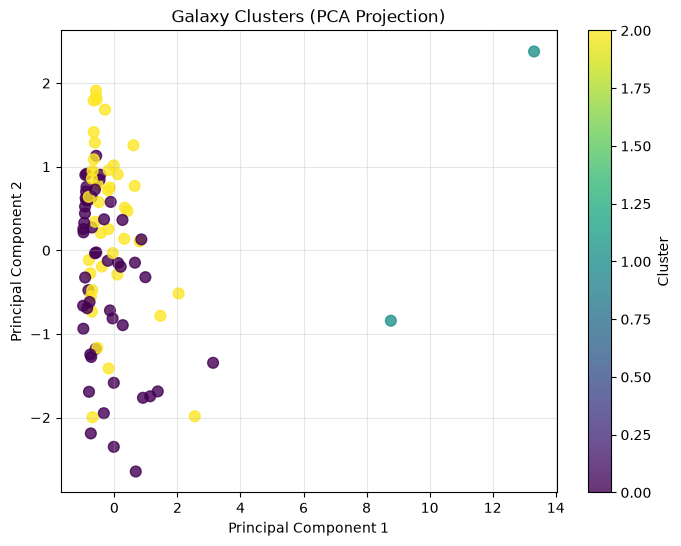

In [9]:
# Cell 10 - Visualize Clusters Using PCA =======================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    s=60,
    alpha=0.8
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Galaxy Clusters (PCA Projection)")

plt.colorbar(scatter, label="Cluster")

plt.grid(alpha=0.3)

plt.show()

In [10]:
# Cell 11 - Compare Cluster Properties =========================

features["cluster"] = clusters

summary = features.group_by("cluster")

summary.groups.aggregate(np.mean)

segment_flux,area,semimajor_axis,semiminor_axis,eccentricity,orientation,axis_ratio,flux_per_pixel,cluster
,pix2,pix,pix,,deg,pix,,
float64,float64,float64,float64,float64,float64,float64,float64,int32
87.9274857745451,29.901960784313726,1.502078118879725,0.9559344467843525,0.7046716762062335,309.5700442047647,1.6554874925009548,1.8049561364327367,0
5581.058793574572,454.5,18.37703366478499,3.3132447877646536,0.9175759448814109,18.317887453322243,7.465639675556653,12.476692968577092,1
54.46782827235403,28.476190476190474,1.4472490366091404,0.8893312594054753,0.7202601936483676,52.84327740077839,1.8418425903410647,1.6046786126082888,2


### Interpreting the Clusters

The table above summarizes the average physical properties of each cluster.

Comparing the average brightness, size, and shape measurements helps determine
whether the clustering algorithm has separated compact objects, extended
galaxies, or other distinct populations within the Hubble field.

In [11]:
# Cell 12 - Save Clustered Catalog =============================

output_file = Path("../data/catalogs/clustered_galaxies.ecsv")

features.write(
    output_file,
    format="ascii.ecsv",
    overwrite=True
)

print("Clustered catalog saved.")

print(output_file)

Clustered catalog saved.
../data/catalogs/clustered_galaxies.ecsv


In [12]:
# Cell 13 - Notebook Status ==================================

from datetime import datetime

print("=" * 60)
print("Notebook Status")
print("=" * 60)

print("Status    : PASS")
print("Notebook  : 09_clustered_galaxies_without_supervised_learning.ipynb")
print("Completed :", datetime.now().strftime("%Y-%m-%d %H:%M"))

Notebook Status
Status    : PASS
Notebook  : 09_clustered_galaxies_without_supervised_learning.ipynb
Completed : 2026-07-27 15:48
